In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print("Path to dataset files:", path)

100%|██████████| 8.89M/8.89M [00:26<00:00, 353kB/s]

Extracting files...


Path to dataset files: C:\Users\praja\.cache\kagglehub\datasets\tmdb\tmdb-movie-metadata\versions\2


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import os
movies_csv = os.path.join(path, "tmdb_5000_movies.csv")

In [7]:
df = pd.read_csv(movies_csv)
cols = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count', 'revenue']
df=df[cols].dropna()
df = df[df['revenue']>0 & (df['budget'] > 0)] 

In [8]:
X = df.drop('revenue',axis=1)
y= df['revenue']




In [9]:
X_train , X_test , y_train ,y_test = train_test_split(X ,y , test_size=0.2 ,random_state=42)



In [10]:
model = LinearRegression()
model.fit(X_train , y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
pred = model.predict(X_test)
print(f"r2_score = ${r2_score(y_test ,pred): .2f}")
print(f"MAE = ${mean_absolute_error(y_test ,pred):.2f}")

r2_score = $ 0.67
MAE = $64064568.92


c:\Users\praja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


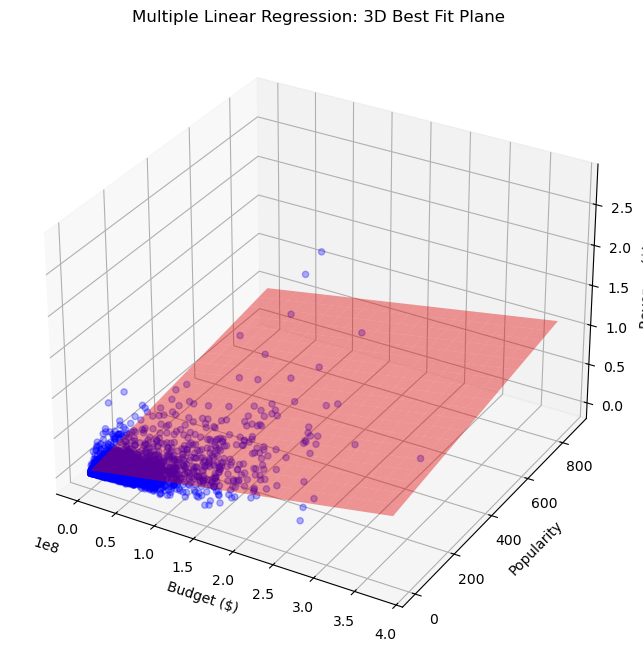

In [15]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# We'll use Budget and Popularity as our X and Y axes for the plane
x_surf = np.linspace(df['budget'].min(), df['budget'].max(), 20)
y_surf = np.linspace(df['popularity'].min(), df['popularity'].max(), 20)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)

# To plot the plane, we provide average values for the other missing features
# (runtime, vote_average, vote_count)
avg_runtime = df['runtime'].mean()
avg_vote_avg = df['vote_average'].mean()
avg_vote_cnt = df['vote_count'].mean()

# Flatten the grid to predict revenue (Z-axis)
combined_data = np.c_[x_surf.ravel(), y_surf.ravel(), 
                     np.full(x_surf.size, avg_runtime),
                     np.full(x_surf.size, avg_vote_avg),
                     np.full(x_surf.size, avg_vote_cnt)]

z_surf = model.predict(combined_data).reshape(x_surf.shape)

# Plot actual data points
ax.scatter(df['budget'], df['popularity'], df['revenue'], color='blue', alpha=0.3, label='Actual Data')
# Plot the Best Fit Plane
ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.4)

ax.set_xlabel('Budget ($)')
ax.set_ylabel('Popularity')
ax.set_zlabel('Revenue ($)')
plt.title('Multiple Linear Regression: 3D Best Fit Plane')
plt.show()

In [16]:
import joblib
import os

# Create the directory if it doesn't exist
if not os.path.exists('../models'):
    os.makedirs('../models')

# Save the model to a file
model_filename = '../models/movie_revenue_model.pkl'
joblib.dump(model, model_filename)

print(f"✅ Model saved successfully to: {model_filename}")


✅ Model saved successfully to: ../models/movie_revenue_model.pkl


In [17]:
import joblib
import pandas as pd

# Load the saved model
loaded_model = joblib.load('../models/movie_revenue_model.pkl')

# Example data for a new "Unknown" movie
# Features: [budget, popularity, runtime, vote_average, vote_count]
new_movie_data = pd.DataFrame([[50000000, 120, 115, 7.2, 1500]], 
                              columns=['budget', 'popularity', 'runtime', 'vote_average', 'vote_count'])

# Make the prediction
prediction = loaded_model.predict(new_movie_data)

print(f"💰 Predicted Revenue: ${prediction[0]:,.2f}")

💰 Predicted Revenue: $211,672,870.58
